<a href="https://colab.research.google.com/github/pajonnakuti/pyDataviz/blob/main/CTD_ARGO_QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating an interactive demo notebook that:
# - Generates synthetic Argo-like and CTD-like profiles in the Indian Ocean
# - Injects intentional errors
# - Applies simplified automated real-time QC tests (Global range, Regional range, Pressure increasing, Spike, Climatology)
# - Produces QC flags (1 = Good, 4 = Bad)
# - Visualizes the results (scatter & profile plots) highlighting flagged points
# - Saves a NetCDF file with the QC'd profile (CF-like / Argo-style minimal)
#
# This cell will run now and produce outputs (tables, plots) and a NetCDF saved to /mnt/data.
# The code is written so you can replace the synthetic data loading part with real Argo/CTD reads
# when you run the notebook in an environment with internet or local NetCDF files.
#
# NOTE: plotting rules followed: matplotlib only, one chart at a time, no explicit color settings.

In [1]:
!pip install xarray netCDF4 matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime
import os

In [ ]:
# helper from the notebook runner for nicer DataFrame display
try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None
np.random.seed(42)

In [ ]:
# -----------------------------
# 1. Generate synthetic Argo profile (Indian Ocean)
# -----------------------------
n = 120
pres = np.linspace(0, 2000, n)  # decibars
# A simple realistic thermocline temperature profile for tropics
temp_true = 28 - 15 * (pres / 2000) ** 0.6 + np.random.normal(0, 0.05, n)
sal_true = 35 + 0.5 * (pres / 2000) ** 0.4 + np.random.normal(0, 0.02, n)

lat, lon = -10.5, 72.8  # central Indian Ocean location (example)

# Make DataFrame
argo_df = pd.DataFrame({
    "PRES_dbar": pres,
    "TEMP_C": temp_true,
    "PSAL": sal_true
})
argo_df.head()

,PRES_dbar,TEMP_C,PSAL
0,0.000000,28.024836,35.015821
1,16.806723,27.140452,35.055730
2,33.613445,26.740032,35.125591
3,50.420168,26.427853,35.086673
4,67.226891,26.029452,35.140436


In [ ]:
# -----------------------------
# 1b. Inject intentional errors
# -----------------------------
# 1) Spike: insert a large spike in TEMP at an isolated level
argo_df.loc[30, "TEMP_C"] += 8.0  # obvious warm spike
# 2) Bad range: set a few temps to impossible values
argo_df.loc[5, "TEMP_C"] = -10.0   # too cold
argo_df.loc[90, "TEMP_C"] = 60.0   # too hot
# 3) Pressure non-monotonic: swap two pressure entries to break monotonicity
argo_df.loc[60, "PRES_dbar"], argo_df.loc[61, "PRES_dbar"] = argo_df.loc[61, "PRES_dbar"], argo_df.loc[60, "PRES_dbar"]
# 4) Salt spike
argo_df.loc[75, "PSAL"] += 4.0

# keep a copy of raw for comparison
argo_raw = argo_df.copy()
argo_raw.head()

,PRES_dbar,TEMP_C,PSAL
0,0.000000,28.024836,35.015821
1,16.806723,27.140452,35.055730
2,33.613445,26.740032,35.125591
3,50.420168,26.427853,35.086673
4,67.226891,26.029452,35.140436


In [ ]:
# -----------------------------
# 2. Define QC tests (simplified)
# -----------------------------
def global_range_test(series, var):
    """Return boolean mask of OK (True) / Bad (False) according to global plausible ranges"""
    if var == "TEMP_C":
        low, high = -2.5, 40.0
    elif var == "PSAL":
        low, high = 2.0, 42.0
    elif var == "PRES_dbar":
        low, high = -5, 11000
    else:
        low, high = -1e9, 1e9
    return (series >= low) & (series <= high)

In [ ]:
def regional_range_test(series, var, lat, lon):
    """Simplified regional limits for Indian Ocean (very conservative)"""
    if var == "TEMP_C":
        # Indian Ocean tropics: roughly -1.8 to 35C (a bit tighter than global)
        return (series >= -1.8) & (series <= 35.0)
    if var == "PSAL":
        return (series >= 30.0) & (series <= 37.5)
    return np.ones_like(series, dtype=bool)

In [ ]:
def pressure_increasing_test(pres_array):
    """Return mask True if pressure is strictly increasing compared to previous point (first point True)"""
    ok = np.ones_like(pres_array, dtype=bool)
    # Check monotonic increasing with index (allow small jitter)
    for i in range(1, len(pres_array)):
        if pres_array[i] <= pres_array[i-1]:
            ok[i] = False
    return ok


In [ ]:
def spike_test(series, pres, window=2, thresh_factor=5.0):
    """Classical spike: point deviates from local median by large amount compared to local MAD/STD.
       Returns boolean mask True=OK, False=spike
    """
    ok = np.ones_like(series, dtype=bool)
    # use median absolute deviation (MAD) in a sliding window
    for i in range(len(series)):
        i0 = max(0, i - window)
        i1 = min(len(series), i + window + 1)
        local = np.delete(series[i0:i1], i - i0)  # exclude the point itself
        if len(local) < 2:
            continue
        med = np.nanmedian(local)
        mad = np.nanmedian(np.abs(local - med)) + 1e-8
        if np.abs(series[i] - med) > thresh_factor * mad:
            ok[i] = False
    return ok

In [ ]:
def climatology_test(series, pres, lat, lon, month=None):
    """Simplified synthetic climatology test.
       We simulate a climatology mean and std as functions of pressure.
       Return True where within 4 sigma, False otherwise.
    """
    # synthetic climatology mean: smooth function of pressure
    clim_mean = 28 - 14 * (pres / 2000) ** 0.6
    clim_std = 0.8 + 0.0007 * pres  # increasing spread with depth (synthetic)
    ok = np.abs(series - clim_mean) <= 4.0 * clim_std
    return ok

In [ ]:
# -----------------------------
# 3. Apply QC: produce flags (1 = Good, 4 = Bad)
# We'll maintain a per-variable flag array (strings '1' or '4' like Argo) and an overall
# profile-level 'TEMP/PSAL' qc summary (worst of variable flags).
# -----------------------------
def compute_qc_flags(df, lat, lon):
    n = len(df)
    # start with all good
    qc_temp = np.ones(n, dtype=int) * 1
    qc_psal = np.ones(n, dtype=int) * 1
    qc_pres = np.ones(n, dtype=int) * 1

    # Global range
    temp_ok_g = global_range_test(df["TEMP_C"].values, "TEMP_C")
    psal_ok_g = global_range_test(df["PSAL"].values, "PSAL")
    pres_ok_g = global_range_test(df["PRES_dbar"].values, "PRES_dbar")

    qc_temp[~temp_ok_g] = 4
    qc_psal[~psal_ok_g] = 4
    qc_pres[~pres_ok_g] = 4

    # Regional range
    temp_ok_r = regional_range_test(df["TEMP_C"].values, "TEMP_C", lat, lon)
    psal_ok_r = regional_range_test(df["PSAL"].values, "PSAL", lat, lon)
    qc_temp[~temp_ok_r] = 4
    qc_psal[~psal_ok_r] = 4

    # Pressure increasing test
    pres_ok_monotonic = pressure_increasing_test(df["PRES_dbar"].values)
    qc_pres[~pres_ok_monotonic] = 4

    # Spike test
    temp_ok_spike = spike_test(df["TEMP_C"].values, df["PRES_dbar"].values, window=2, thresh_factor=8.0)
    psal_ok_spike = spike_test(df["PSAL"].values, df["PRES_dbar"].values, window=2, thresh_factor=8.0)
    qc_temp[~temp_ok_spike] = 4
    qc_psal[~psal_ok_spike] = 4

    # Climatology test
    temp_ok_clim = climatology_test(df["TEMP_C"].values, df["PRES_dbar"].values, lat, lon)
    qc_temp[~temp_ok_clim] = 4

    # Combine into DataFrame columns
    df_out = df.copy()
    df_out["TEMP_QC"] = qc_temp.astype(str)
    df_out["PSAL_QC"] = qc_psal.astype(str)
    df_out["PRES_QC"] = qc_pres.astype(str)

    # Overall variable quality: worst flag between TEMP and PSAL (4 if any is 4)
    overall = np.where((qc_temp == 4) | (qc_psal == 4) | (qc_pres == 4), 4, 1)
    df_out["PROFILE_QC"] = overall.astype(str)
    return df_out

argo_qc = compute_qc_flags(argo_df, lat, lon)

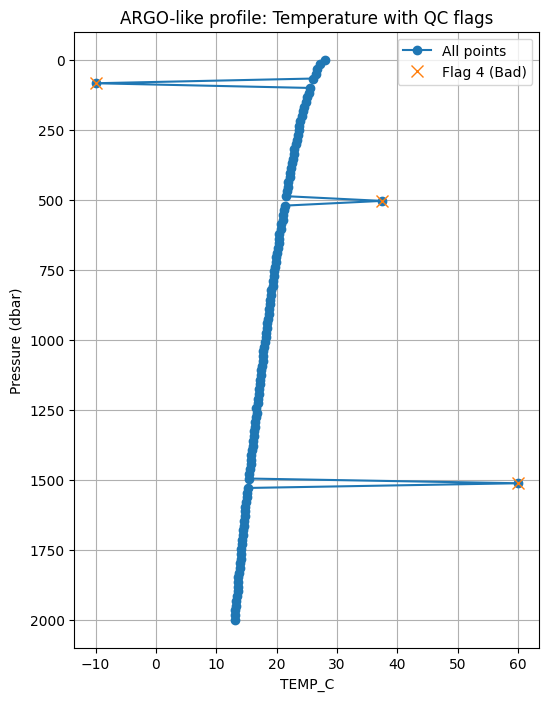

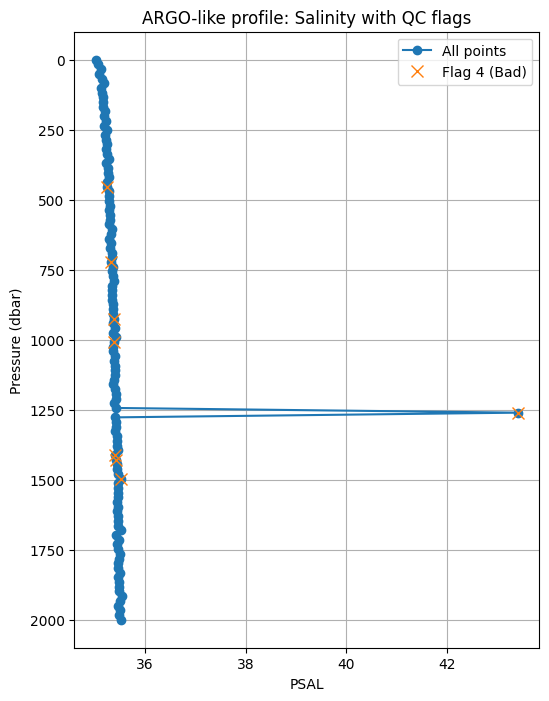

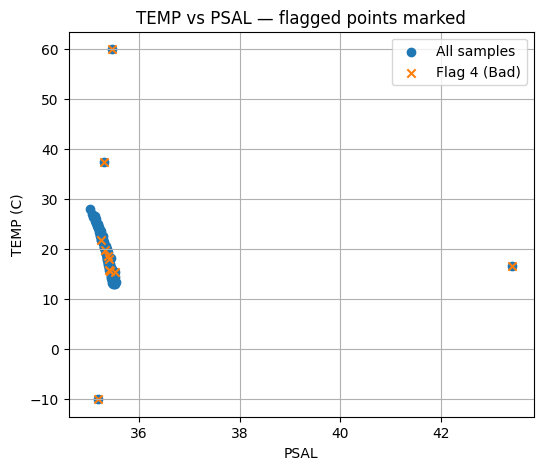

In [ ]:
# -----------------------------
# 4. Visualizations
# - TEMP profile with flagged points
# - PSAL profile with flagged points
# - Scatter TEMP vs PRES colored by flag (but per plotting rules we won't explicitly set colors)
# -----------------------------
def plot_profile_with_flags(df, var, qc_col, title):
    fig, ax = plt.subplots(figsize=(6,8))
    # Good points (QC == '1')
    ok = df[qc_col] == '1'
    bad = df[qc_col] == '4'
    ax.plot(df[var], df["PRES_dbar"], linestyle='-', marker='o', label='All points')
    ax.plot(df[var][bad], df["PRES_dbar"][bad], linestyle='None', marker='x', markersize=8, label='Flag 4 (Bad)')
    ax.invert_yaxis()
    ax.set_xlabel(var)
    ax.set_ylabel("Pressure (dbar)")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    plt.show()

# Plot Temperature profile
plot_profile_with_flags(argo_qc, "TEMP_C", "TEMP_QC", "ARGO-like profile: Temperature with QC flags")
# Plot Salinity profile
plot_profile_with_flags(argo_qc, "PSAL", "PSAL_QC", "ARGO-like profile: Salinity with QC flags")

# Simple scatter of TEMP vs PSAL, marking bad points
fig, ax = plt.subplots(figsize=(6,5))
bad_mask = (argo_qc["PROFILE_QC"] == '4')

ax.scatter(argo_qc["PSAL"], argo_qc["TEMP_C"],  label='All samples')
ax.scatter(argo_qc["PSAL"][bad_mask], argo_qc["TEMP_C"][bad_mask],  marker='x', label='Flag 4 (Bad)')
ax.set_xlabel("PSAL")
ax.set_ylabel("TEMP (C)")
ax.set_title("TEMP vs PSAL — flagged points marked")
ax.grid(True)
ax.legend()
plt.show()

In [ ]:
# -----------------------------
# 5. Analyze QC flags: summary counts and indices of bad points
# -----------------------------
summary = {
    "total_points": len(argo_qc),
    "temp_bad": int((argo_qc["TEMP_QC"] == '4').sum()),
    "psal_bad": int((argo_qc["PSAL_QC"] == '4').sum()),
    "pres_bad": int((argo_qc["PRES_QC"] == '4').sum()),
    "profile_bad": int((argo_qc["PROFILE_QC"] == '4').sum())
}

summary_df = pd.DataFrame([summary])

# Display summary
if display_dataframe_to_user is not None:
    display_dataframe_to_user("ARGO QC Summary", summary_df)
else:
    print("\nQC Summary:")
    print(summary_df.to_string(index=False))

# Show the rows that were flagged bad (profile-level)
bad_rows = argo_qc[argo_qc["PROFILE_QC"] == '4'][["PRES_dbar","TEMP_C","PSAL","TEMP_QC","PSAL_QC","PRES_QC"]]
if display_dataframe_to_user is not None:
    display_dataframe_to_user("Bad rows (ARGO synthetic)", bad_rows)
else:
    print("\nBad rows (sample):")
    print(bad_rows.head(20).to_string(index=False))


QC Summary:
 total_points  temp_bad  psal_bad  pres_bad  profile_bad
          120         3         8         0           11

Bad rows (sample):
  PRES_dbar     TEMP_C      PSAL TEMP_QC PSAL_QC PRES_QC
  84.033613 -10.000000 35.184524       4       1       1
 453.781513  21.858776 35.249837       1       4       1
 504.201681  37.407921 35.293147       4       1       1
 722.689076  19.840825 35.316352       1       4       1
 924.369748  18.606375 35.383738       1       4       1
1008.403361  18.029918 35.392713       1       4       1
1260.504202  16.670064 43.423402       1       4       1
1411.764706  15.788452 35.407420       1       4       1
1428.571429  15.717058 35.418281       1       4       1
1495.798319  15.424893 35.522205       1       4       1
1512.605042  60.000000 35.458563       4       1       1


In [ ]:
# -----------------------------
# 6. Prepare NetCDF (CF-like minimal) for distribution
# -----------------------------
# Build xarray Dataset
ds = xr.Dataset(
    {
        "TEMP_C": ("obs", argo_qc["TEMP_C"].values),
        "PSAL": ("obs", argo_qc["PSAL"].values),
        "PRES_dbar": ("obs", argo_qc["PRES_dbar"].values),
        "TEMP_QC": ("obs", argo_qc["TEMP_QC"].values.astype("S1")),
        "PSAL_QC": ("obs", argo_qc["PSAL_QC"].values.astype("S1")),
        "PRES_QC": ("obs", argo_qc["PRES_QC"].values.astype("S1")),
        "PROFILE_QC": ("obs", argo_qc["PROFILE_QC"].values.astype("S1")),
    },
    coords={
        "obs": np.arange(len(argo_qc)),
        "latitude": lat,
        "longitude": lon,
        "time": np.datetime64(datetime.utcnow())
    },
    attrs={
        "title": "Synthetic ARGO-style profile (QC demo)",
        "Conventions": "CF-1.7, ACDD-1.3 (minimal)",
        "institution": "Demonstration Notebook",
        "source": "synthetic, for QC demo"
    }
)

os.makedirs("/content/", exist_ok=True)
nc_path = "/content/argo_qc_demo_profile.nc"
ds.to_netcdf(nc_path)

print(f"\nSaved QC'd NetCDF to: {nc_path}")


Saved QC'd NetCDF to: /content/argo_qc_demo_profile.nc


/tmp/ipython-input-628631258.py:19: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "time": np.datetime64(datetime.utcnow())


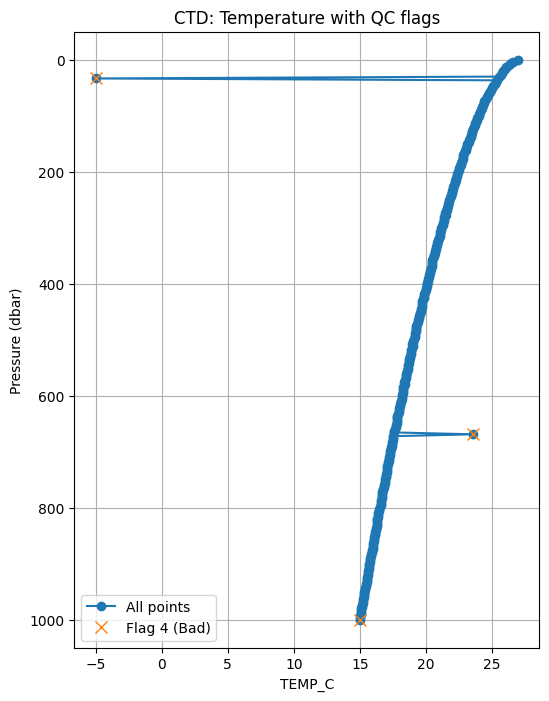


CTD QC Summary:
 total_points  temp_bad  psal_bad  pres_bad  profile_bad
          300         3        25         1           29
Saved CTD QC'd NetCDF to: /mnt/data/ctd_qc_demo_profile.nc

Sample ARGO rows:
  PRES_dbar     TEMP_C      PSAL TEMP_QC PSAL_QC PRES_QC PROFILE_QC
  0.000000  28.024836 35.015821       1       1       1          1
 16.806723  27.140452 35.055730       1       1       1          1
 33.613445  26.740032 35.125591       1       1       1          1
 50.420168  26.427853 35.086673       1       1       1          1
 67.226891  26.029452 35.140436       1       1       1          1
 84.033613 -10.000000 35.184524       4       1       1          4
100.840336  25.580607 35.131549       1       1       1          1
117.647059  25.297922 35.149661       1       1       1          1
134.453782  25.007479 35.171812       1       1       1          1
151.260504  24.840667 35.167942       1       1       1          1
168.067227  24.582429 35.154661       1       1      

/tmp/ipython-input-2690966144.py:52: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "time": np.datetime64(datetime.utcnow())


In [ ]:
# -----------------------------
# 7. Create a short CTD dataset and run same QC (CTD are typically high-resolution)
# -----------------------------
ctd_n = 300
ctd_pres = np.linspace(0, 1000, ctd_n)
ctd_temp = 27 - 12 * (ctd_pres / 1000) ** 0.6 + np.random.normal(0, 0.02, ctd_n)
ctd_psal = 35 + 0.3 * (ctd_pres / 1000) ** 0.4 + np.random.normal(0, 0.01, ctd_n)
ctd_df = pd.DataFrame({"PRES_dbar": ctd_pres, "TEMP_C": ctd_temp, "PSAL": ctd_psal})

# Inject some errors into CTD
ctd_df.loc[10, "TEMP_C"] = -5.0
ctd_df.loc[150, "PSAL"] = 50.0
ctd_df.loc[200, "TEMP_C"] += 6.0  # spike
# make a small non-monotonic pressure
ctd_df.loc[120, "PRES_dbar"], ctd_df.loc[121, "PRES_dbar"] = ctd_df.loc[121, "PRES_dbar"], ctd_df.loc[120, "PRES_dbar"]

ctd_qc = compute_qc_flags(ctd_df, lat, lon)

# Plot CTD temp
plot_profile_with_flags(ctd_qc, "TEMP_C", "TEMP_QC", "CTD: Temperature with QC flags")

# CTD summary
ctd_summary = {
    "total_points": len(ctd_qc),
    "temp_bad": int((ctd_qc["TEMP_QC"] == '4').sum()),
    "psal_bad": int((ctd_qc["PSAL_QC"] == '4').sum()),
    "pres_bad": int((ctd_qc["PRES_QC"] == '4').sum()),
    "profile_bad": int((ctd_qc["PROFILE_QC"] == '4').sum())
}
ctd_summary_df = pd.DataFrame([ctd_summary])
if display_dataframe_to_user is not None:
    display_dataframe_to_user("CTD QC Summary", ctd_summary_df)
else:
    print("\nCTD QC Summary:")
    print(ctd_summary_df.to_string(index=False))

# Save CTD to NetCDF as well
ds_ctd = xr.Dataset(
    {
        "TEMP_C": ("obs", ctd_qc["TEMP_C"].values),
        "PSAL": ("obs", ctd_qc["PSAL"].values),
        "PRES_dbar": ("obs", ctd_qc["PRES_dbar"].values),
        "TEMP_QC": ("obs", ctd_qc["TEMP_QC"].values.astype("S1")),
        "PSAL_QC": ("obs", ctd_qc["PSAL_QC"].values.astype("S1")),
        "PRES_QC": ("obs", ctd_qc["PRES_QC"].values.astype("S1")),
        "PROFILE_QC": ("obs", ctd_qc["PROFILE_QC"].values.astype("S1")),
    },
    coords={
        "obs": np.arange(len(ctd_qc)),
        "latitude": lat,
        "longitude": lon,
        "time": np.datetime64(datetime.utcnow())
    },
    attrs={
        "title": "Synthetic CTD profile (QC demo)",
        "Conventions": "CF-1.7, ACDD-1.3 (minimal)",
        "institution": "Demonstration Notebook",
        "source": "synthetic, for QC demo"
    }
)

nc_ctd_path = "/mnt/data/ctd_qc_demo_profile.nc"
ds_ctd.to_netcdf(nc_ctd_path)
print(f"Saved CTD QC'd NetCDF to: {nc_ctd_path}")

# Final user-friendly outputs: small sample table
sample_table = argo_qc.head(12)[["PRES_dbar","TEMP_C","PSAL","TEMP_QC","PSAL_QC","PRES_QC","PROFILE_QC"]]
if display_dataframe_to_user is not None:
    display_dataframe_to_user("Sample ARGO QC rows (first 12 obs)", sample_table)
else:
    print("\nSample ARGO rows:\n", sample_table.to_string(index=False))

# Provide final message about how to adapt the notebook to real Argo/CTD files
print("\n\nNotebook demo complete. To run with real Argo floats or CTD files:")
print("- Replace synthetic data creation with reading your NetCDF/CSV.")
print("- For Argo real-time QC, use the exact range/climatology tables and follow Argo DMQC rules.")
print("- The produced NetCDF files are CF-like; adapt variable names/attributes to the exact Argo file spec if needed.")

# List saved files for download
print("\nFiles saved:")
for p in [nc_path, nc_ctd_path]:
    print(" -", p)


In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# Open dataset
url = "/content/2901340_prof.nc"
ds = xr.open_dataset(url)
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:                       (N_PROF: 312, N_PARAM: 3, N_LEVELS: 59,
                                   N_CALIB: 1, N_HISTORY: 0)
Dimensions without coordinates: N_PROF, N_PARAM, N_LEVELS, N_CALIB, N_HISTORY
Data variables: (12/64)
    DATA_TYPE                     object 8B ...
    FORMAT_VERSION                object 8B ...
    HANDBOOK_VERSION              object 8B ...
    REFERENCE_DATE_TIME           object 8B ...
    DATE_CREATION                 object 8B ...
    DATE_UPDATE                   object 8B ...
    ...                            ...
    HISTORY_ACTION                (N_HISTORY, N_PROF) object 0B ...
    HISTORY_PARAMETER             (N_HISTORY, N_PROF) object 0B ...
    HISTORY_START_PRES            (N_HISTORY, N_PROF) float32 0B ...
    HISTORY_STOP_PRES             (N_HISTORY, N_PROF) float32 0B ...
    HISTORY_PREVIOUS_VALUE        (N_HISTORY, N_PROF) float32 0B ...
    HISTORY_QCTEST                (N_HISTORY, N_PROF) object 0B ..

In [46]:
# Choose a particular profile cycle (e.g. cycle 10)
cycle = 17
profile = ds.sel(N_PROF=cycle)

In [47]:
# Extract data arrays
p = profile.PRES.values
t = profile.TEMP.values
s = profile.PSAL.values

t_adj = profile.TEMP_ADJUSTED.values
s_adj = profile.PSAL_ADJUSTED.values

qc_t = profile.TEMP_QC.values
qc_s = profile.PSAL_QC.values

In [48]:
print(qc_t,qc_s)
qc_t_str = np.array([x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in qc_t])
qc_s_str = np.array([x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in qc_s])
print(qc_t_str,qc_s_str)

[b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4'] [b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4' b'4'
 b'4' b'4' b'4']
['4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4'
 '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4'
 '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4'
 '4' '4' '4' '4' '4'] ['4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4'
 '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4' '4'
 '4' '4' '4

In [49]:
print(bad)

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False  True  True]


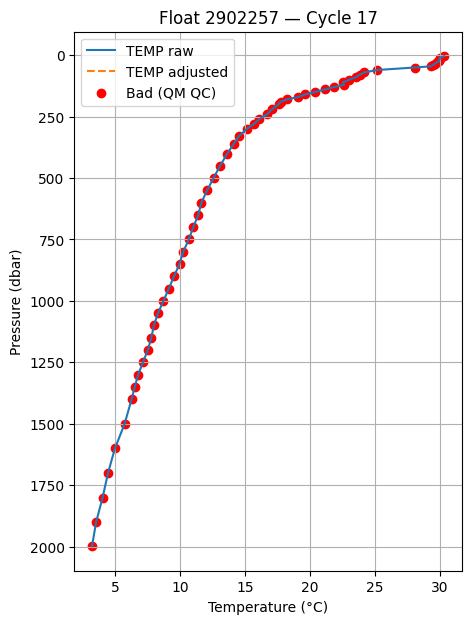

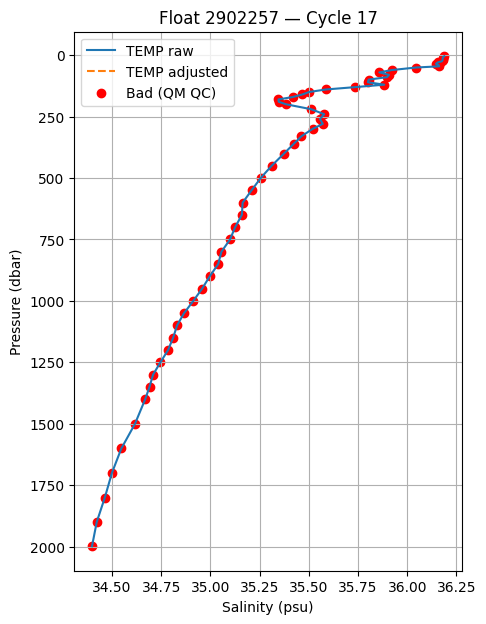

In [50]:
# Plot temperature profiles
plt.figure(figsize=(5,7))
plt.plot(t, p, label="TEMP raw")
plt.plot(t_adj, p, '--', label="TEMP adjusted")
# Mark bad QC in raw (qc_t != '1')
bad = qc_t_str != '1'
plt.scatter(t[bad], p[bad], color='red', label="Bad (QM QC)")
plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (dbar)")
plt.title(f"Float 2902257 — Cycle {cycle}")
plt.legend()
plt.grid(True)
plt.show()


# Plot temperature profiles
plt.figure(figsize=(5,7))
plt.plot(s, p, label="TEMP raw")
plt.plot(s_adj, p, '--', label="TEMP adjusted")
# Mark bad QC in raw (qc_t != '1')
bad = qc_s_str != '1'
plt.scatter(s[bad], p[bad], color='red', label="Bad (QM QC)")
plt.gca().invert_yaxis()
plt.xlabel("Salinity (psu)")
plt.ylabel("Pressure (dbar)")
plt.title(f"Float 2902257 — Cycle {cycle}")
plt.legend()
plt.grid(True)
plt.show()


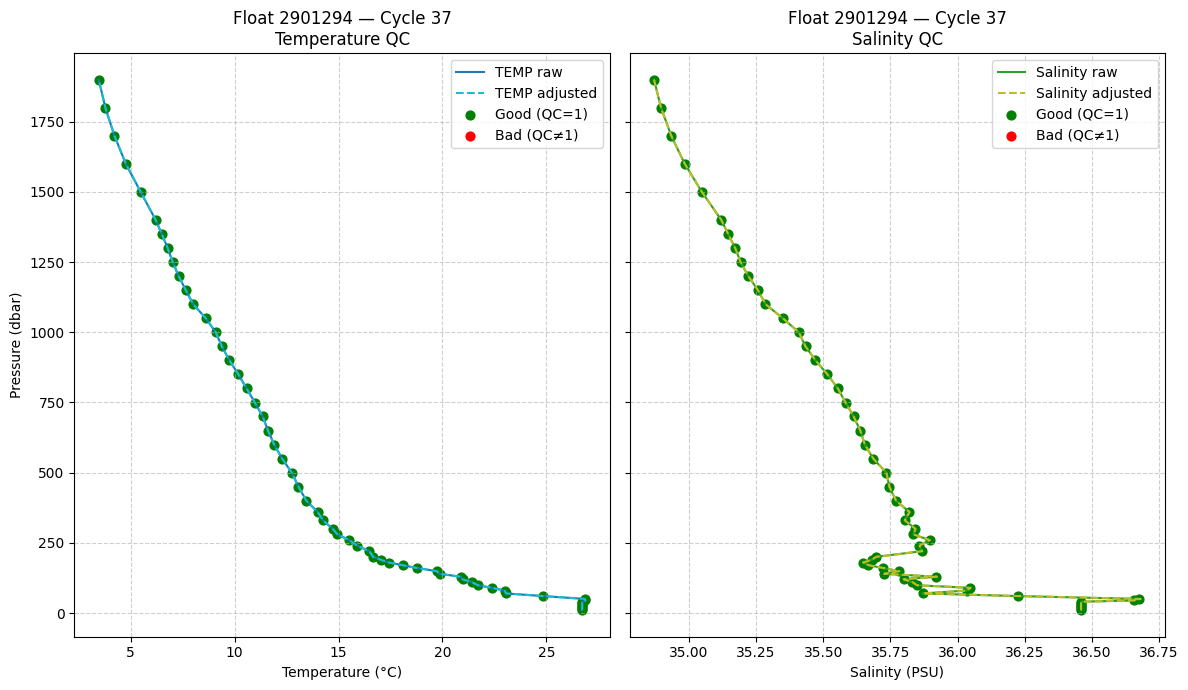

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Convert byte strings to text
qc_t_str = np.array([x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in qc_t])
qc_s_str = np.array([x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in qc_s])

# QC masks
good_t = qc_t_str == '1'
bad_t = ~good_t
good_s = qc_s_str == '1'
bad_s = ~good_s

# Sort by pressure
sort_idx = np.argsort(p)
p_sorted = p[sort_idx]
t_sorted = t[sort_idx]
t_adj_sorted = t_adj[sort_idx]
s_sorted = s[sort_idx]
s_adj_sorted = s_adj[sort_idx]
bad_t_sorted = bad_t[sort_idx]
bad_s_sorted = bad_s[sort_idx]
good_t_sorted = good_t[sort_idx]
good_s_sorted = good_s[sort_idx]

# Subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

# ---- Temperature ----
axes[0].plot(t_sorted, p_sorted, label="TEMP raw", color="tab:blue")
axes[0].plot(t_adj_sorted, p_sorted, '--', label="TEMP adjusted", color="tab:cyan")
axes[0].scatter(t_sorted[good_t_sorted], p_sorted[good_t_sorted], color='green', s=40, label="Good (QC=1)")
axes[0].scatter(t_sorted[bad_t_sorted], p_sorted[bad_t_sorted], color='red', s=40, label="Bad (QC≠1)")
#axes[0].invert_yaxis()
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Pressure (dbar)")
axes[0].set_title(f"Float 2901294 — Cycle {cycle}\nTemperature QC")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---- Salinity ----
axes[1].plot(s_sorted, p_sorted, label="Salinity raw", color="tab:green")
axes[1].plot(s_adj_sorted, p_sorted, '--', label="Salinity adjusted", color="tab:olive")
axes[1].scatter(s_sorted[good_s_sorted], p_sorted[good_s_sorted], color='green', s=40, label="Good (QC=1)")
axes[1].scatter(s_sorted[bad_s_sorted], p_sorted[bad_s_sorted], color='red', s=40, label="Bad (QC≠1)")
#axes[1].invert_yaxis()
axes[1].set_xlabel("Salinity (PSU)")
axes[1].set_title(f"Float 2901294 — Cycle {cycle}\nSalinity QC")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Example arrays (replace with your data)
# p = pressure, t = temperature raw, t_adj = adjusted temp
# s = salinity raw, s_adj = adjusted salinity
# qc_t, qc_s = QC flags for temp & salinity
# cycle = cycle number

# Convert QC flags to arrays if strings
bad_t = qc_t != '1'
good_t = qc_t == '1'
bad_s = qc_s != '1'
good_s = qc_s == '1'

# Create interactive subplots
fig = make_subplots(rows=1, cols=2, shared_yaxes=True,
                    subplot_titles=(
                        f"Float 2901294 — Cycle {cycle}<br>Temperature QC",
                        f"Float 2901294 — Cycle {cycle}<br>Salinity QC"
                    ))

# ---- Temperature Profile ----
fig.add_trace(go.Scatter(
    x=t, y=p, mode='lines', name='TEMP raw',
    line=dict(color='blue')), row=1, col=1)

fig.add_trace(go.Scatter(
    x=t_adj, y=p, mode='lines', name='TEMP adjusted',
    line=dict(color='cyan', dash='dash')), row=1, col=1)

# Good data
fig.add_trace(go.Scatter(
    x=t[good_t], y=p[good_t], mode='markers',
    marker=dict(color='green', size=6, symbol='circle'),
    name='Good (QC=1)'), row=1, col=1)

# Bad data
fig.add_trace(go.Scatter(
    x=t[bad_t], y=p[bad_t], mode='markers',
    marker=dict(color='red', size=7, symbol='x'),
    name='Bad (QC≠1)'), row=1, col=1)

# ---- Salinity Profile ----
fig.add_trace(go.Scatter(
    x=s, y=p, mode='lines', name='Salinity raw',
    line=dict(color='green')), row=1, col=2)

fig.add_trace(go.Scatter(
    x=s_adj, y=p, mode='lines', name='Salinity adjusted',
    line=dict(color='olive', dash='dash')), row=1, col=2)

# Good data
fig.add_trace(go.Scatter(
    x=s[good_s], y=p[good_s], mode='markers',
    marker=dict(color='green', size=6, symbol='circle'),
    name='Good (QC=1)', showlegend=False), row=1, col=2)

# Bad data
fig.add_trace(go.Scatter(
    x=s[bad_s], y=p[bad_s], mode='markers',
    marker=dict(color='red', size=7, symbol='x'),
    name='Bad (QC≠1)', showlegend=False), row=1, col=2)

# Layout customization
fig.update_layout(
    height=600, width=1100,
    title_text="ARGO Float 2901294 — Realtime & Delayed-mode QC Visualization",
    template='plotly_white',
    legend=dict(x=1.05, y=1)
)

# Reverse y-axis (pressure increases downward)
fig.update_yaxes(autorange='reversed', title_text='Pressure (dbar)', row=1, col=1)
fig.update_xaxes(title_text='Temperature (°C)', row=1, col=1)
fig.update_xaxes(title_text='Salinity (PSU)', row=1, col=2)

fig.show()


In [ ]:
import pandas as pd
import numpy as np
import re
import xarray as xr

def read_cnv(file_path):
    encodings = ['utf-8', 'latin1', 'ISO-8859-1']
    text = None
    for enc in encodings:
        try:
            with open(file_path, 'r', encoding=enc, errors='ignore') as f:
                text = f.readlines()
            break
        except UnicodeDecodeError:
            continue
    if text is None:
        raise ValueError("Unable to decode CNV file with supported encodings.")

    header_lines = []
    data_start = 0
    for i, line in enumerate(text):
        if line.strip().startswith('*') or line.strip().startswith('#'):
            header_lines.append(line.strip())
        elif re.match(r"^[\s\d\.\-]+", line):
            data_start = i
            break

    # Try extracting column names
    column_names = []
    for h in header_lines:
        if "# name" in h.lower():
            match = re.findall(r'=\s*(\S+):?', h)
            if match:
                column_names.append(match[0])

    df = pd.read_csv(
        file_path,
        skiprows=data_start,
        sep=r'\s+',
        names=column_names if column_names else None,
        encoding='latin1',
        engine='python'
    )
    df = df.dropna(how="all")
    return df, header_lines


def qc_ctd(df):
    # Try multiple possible column identifiers
    colmap = {}
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in ['pr', 'pres']):
            colmap['pressure'] = c
        elif any(k in cl for k in ['t0', 'temp']):
            colmap['temperature'] = c
        elif any(k in cl for k in ['sal']):
            colmap['salinity'] = c

    if len(colmap) < 3:
        raise ValueError(f"Could not find required columns in file. Found: {colmap}")

    pres_col = colmap['pressure']
    temp_col = colmap['temperature']
    sal_col = colmap['salinity']

    df = df.copy()
    df["TEMP_QC"] = 1
    df["PSAL_QC"] = 1
    df["PRES_QC"] = 1

    # --- 1. Global Range Test ---
    df.loc[(df[temp_col] < -2.5) | (df[temp_col] > 40), "TEMP_QC"] = 4
    df.loc[(df[sal_col] < 0) | (df[sal_col] > 42), "PSAL_QC"] = 4
    df.loc[(df[pres_col] < -5) | (df[pres_col] > 12000), "PRES_QC"] = 4

    # --- 2. Pressure Increasing Test ---
    if not (df[pres_col].is_monotonic_increasing or df[pres_col].is_monotonic_decreasing):
        df.loc[:, "PRES_QC"] = 4

    # --- 3. Spike Test ---
    for col, qc_col in [(temp_col, "TEMP_QC"), (sal_col, "PSAL_QC")]:
        diffs = np.abs(np.gradient(df[col]))
        df.loc[diffs > (5 * np.nanmedian(diffs)), qc_col] = 4

    # --- 4. Simple Climatology Check ---
    df.loc[(df[temp_col] < 0) | (df[temp_col] > 35), "TEMP_QC"] = 4

    return df, pres_col, temp_col, sal_col


def save_qc_netcdf(df, pres_col, temp_col, sal_col, out_file="ctd_qc_01.nc"):
    ds = xr.Dataset({
        "PRES": ("N_LEVELS", df[pres_col].values),
        "TEMP": ("N_LEVELS", df[temp_col].values),
        "PSAL": ("N_LEVELS", df[sal_col].values),
        "PRES_QC": ("N_LEVELS", df["PRES_QC"].astype(str).values),
        "TEMP_QC": ("N_LEVELS", df["TEMP_QC"].astype(str).values),
        "PSAL_QC": ("N_LEVELS", df["PSAL_QC"].astype(str).values),
    })
    ds.to_netcdf(out_file)
    print(f"✅ Saved QC'd CTD data to: {out_file}")
    return out_file


# === RUN ===
file_path = "/content/ctd-01.cnv"  # your CTD file
df, meta = read_cnv(file_path)
print("Columns found:", df.columns.tolist())

df_qc, pres_col, temp_col, sal_col = qc_ctd(df)
save_qc_netcdf(df_qc, pres_col, temp_col, sal_col, "ctd_qc_01.nc")


Columns found: ['prDM:', 't090C:', 'c0S/m:', 'flC:', 'scan:', 'timeS:', 'depSM:', 'sal00:', 'potemp090C:', 'sigma-00:', 'gpa:', 'flag:']
✅ Saved QC'd CTD data to: ctd_qc_01.nc


'ctd_qc_01.nc'

In [ ]:
df_qc

,prDM:,t090C:,c0S/m:,flC:,scan:,timeS:,depSM:,sal00:,potemp090C:,sigma-00:,gpa:,flag:,TEMP_QC,PSAL_QC,PRES_QC
0,0.011,29.0358,5.652222,-0.0079,5528,230.297,0.0,34.4455,29.0358,21.6363,0.000,0.0,1,1,1
1,2.011,29.0358,5.652222,-0.0079,5528,230.297,2.0,34.4455,29.0353,21.6360,0.123,0.0,1,1,1
2,4.022,29.0331,5.651914,-0.0078,5618,234.046,4.0,34.4448,29.0321,21.6365,0.246,0.0,1,1,1
3,6.033,29.0277,5.651312,-0.0079,5696,237.281,6.0,34.4439,29.0263,21.6379,0.370,0.0,1,1,1
4,8.044,29.0308,5.651545,-0.0078,5802,241.725,8.0,34.4427,29.0289,21.6361,0.493,0.0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,1669.792,3.5677,3.273712,-0.0113,76209,3175.337,1654.0,34.8094,3.4391,27.6974,20.970,0.0,1,1,1
828,1671.819,3.5660,3.273639,-0.0108,76327,3180.230,1656.0,34.8093,3.4372,27.6975,20.981,0.0,1,1,1
829,1673.846,3.5642,3.273555,-0.0110,76523,3188.417,1658.0,34.8092,3.4353,27.6977,20.992,0.0,1,1,1
830,1675.873,3.5573,3.273008,-0.0110,76707,3196.101,1660.0,34.8090,3.4283,27.6982,21.002,0.0,1,1,1


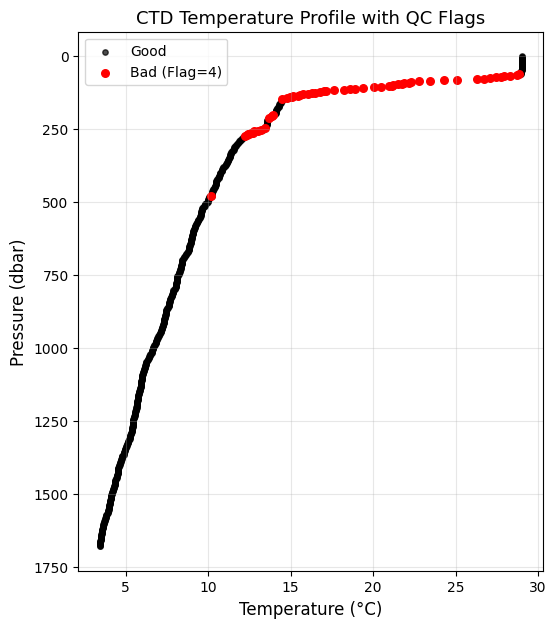

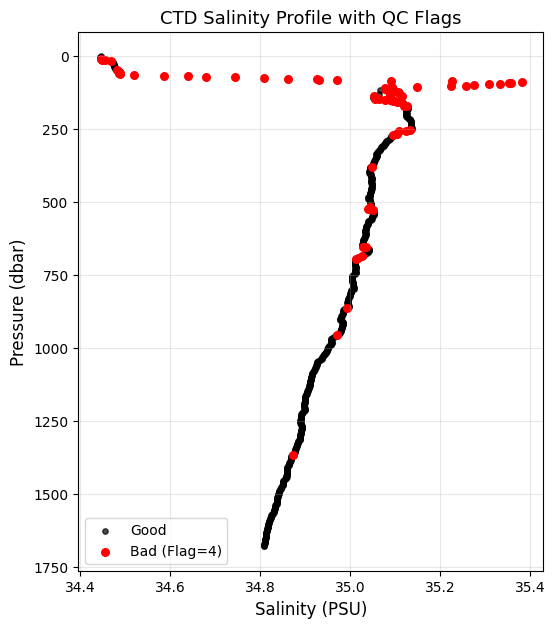

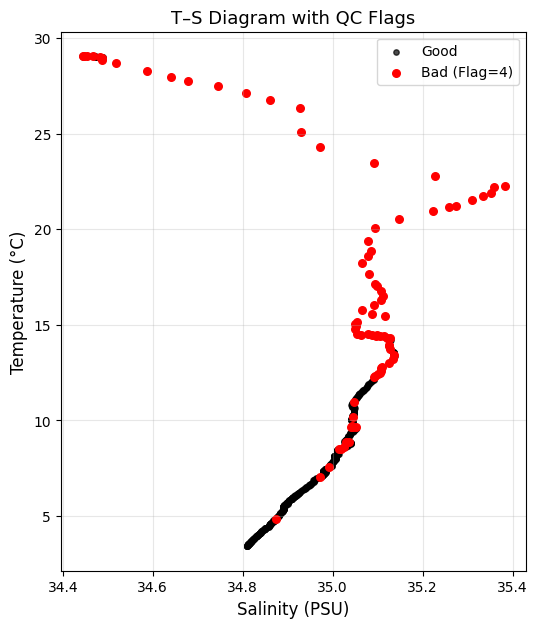

In [ ]:
# --- Visualization ---

plt.rcParams.update({'figure.figsize': (6, 7), 'axes.labelsize': 12, 'axes.titlesize': 13})

# 1️⃣ Temperature vs Pressure
plt.figure()
plt.scatter(df_qc[temp_col], df_qc[pres_col], s=15, c='k', label="Good", alpha=0.7)
bad = df_qc[df_qc["TEMP_QC"] == 4]
if not bad.empty:
    plt.scatter(bad[temp_col], bad[pres_col], s=30, c='r', label="Bad (Flag=4)")
plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (dbar)")
plt.title("CTD Temperature Profile with QC Flags")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2️⃣ Salinity vs Pressure
plt.figure()
plt.scatter(df_qc[sal_col], df_qc[pres_col], s=15, c='k', label="Good", alpha=0.7)
bad = df_qc[df_qc["PSAL_QC"] == 4]
if not bad.empty:
    plt.scatter(bad[sal_col], bad[pres_col], s=30, c='r', label="Bad (Flag=4)")
plt.gca().invert_yaxis()
plt.xlabel("Salinity (PSU)")
plt.ylabel("Pressure (dbar)")
plt.title("CTD Salinity Profile with QC Flags")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3️⃣ T-S Diagram
plt.figure()
plt.scatter(df_qc[sal_col], df_qc[temp_col], s=15, c='k', label="Good", alpha=0.7)
bad = df_qc[(df_qc["TEMP_QC"] == 4) | (df_qc["PSAL_QC"] == 4)]
if not bad.empty:
    plt.scatter(bad[sal_col], bad[temp_col], s=30, c='r', label="Bad (Flag=4)")
plt.xlabel("Salinity (PSU)")
plt.ylabel("Temperature (°C)")
plt.title("T–S Diagram with QC Flags")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import re
import xarray as xr
import plotly.graph_objects as go

# --- CNV Reader ---
def read_cnv(file_path):
    encodings = ['utf-8', 'latin1', 'ISO-8859-1']
    text = None
    for enc in encodings:
        try:
            with open(file_path, 'r', encoding=enc, errors='ignore') as f:
                text = f.readlines()
            break
        except UnicodeDecodeError:
            continue

    header_lines = []
    data_start = 0
    for i, line in enumerate(text):
        if line.strip().startswith('*') or line.strip().startswith('#'):
            header_lines.append(line.strip())
        elif re.match(r"^[\s\d\.\-]+", line):
            data_start = i
            break

    column_names = []
    for h in header_lines:
        if "# name" in h.lower():
            match = re.findall(r'=\s*(\S+):?', h)
            if match:
                column_names.append(match[0])

    df = pd.read_csv(
        file_path,
        skiprows=data_start,
        sep=r'\s+',
        names=column_names if column_names else None,
        encoding='latin1',
        engine='python'
    ).dropna(how="all")
    return df, header_lines


# --- QC Tests ---
def qc_ctd(df):
    colmap = {}
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in ['pr', 'pres']):
            colmap['pressure'] = c
        elif any(k in cl for k in ['t0', 'temp']):
            colmap['temperature'] = c
        elif any(k in cl for k in ['sal']):
            colmap['salinity'] = c

    if len(colmap) < 3:
        raise ValueError(f"Could not find required columns. Found: {colmap}")

    pres_col, temp_col, sal_col = colmap['pressure'], colmap['temperature'], colmap['salinity']

    df = df.copy()
    df["TEMP_QC"] = 1
    df["PSAL_QC"] = 1
    df["PRES_QC"] = 1

    # Global range test
    df.loc[(df[temp_col] < -2.5) | (df[temp_col] > 40), "TEMP_QC"] = 4
    df.loc[(df[sal_col] < 0) | (df[sal_col] > 42), "PSAL_QC"] = 4

    # Pressure range
    df.loc[(df[pres_col] < -5) | (df[pres_col] > 12000), "PRES_QC"] = 4

    # Spike test
    for col, qc_col in [(temp_col, "TEMP_QC"), (sal_col, "PSAL_QC")]:
        diffs = np.abs(np.gradient(df[col]))
        df.loc[diffs > (5 * np.nanmedian(diffs)), qc_col] = 4

    # Climatology check (very basic)
    df.loc[(df[temp_col] < 0) | (df[temp_col] > 35), "TEMP_QC"] = 4

    return df, pres_col, temp_col, sal_col


# --- Save QC result ---
def save_qc_netcdf(df, pres_col, temp_col, sal_col, out_file="ctd_qc_plotly.nc"):
    ds = xr.Dataset({
        "PRES": ("N_LEVELS", df[pres_col]),
        "TEMP": ("N_LEVELS", df[temp_col]),
        "PSAL": ("N_LEVELS", df[sal_col]),
        "PRES_QC": ("N_LEVELS", df["PRES_QC"].astype(str)),
        "TEMP_QC": ("N_LEVELS", df["TEMP_QC"].astype(str)),
        "PSAL_QC": ("N_LEVELS", df["PSAL_QC"].astype(str)),
    })
    ds.to_netcdf(out_file)
    print(f"✅ QC'd data saved: {out_file}")


# ========== Run pipeline ==========
file_path = "/content/ctd-01.cnv"  # your CTD file
df, meta = read_cnv(file_path)
df_qc, pres_col, temp_col, sal_col = qc_ctd(df)
save_qc_netcdf(df_qc, pres_col, temp_col, sal_col, "ctd_qc_plotly.nc")


# ========== INTERACTIVE PLOTS ==========

# 1️⃣ Temperature vs Pressure
fig1 = go.Figure()
good = df_qc[df_qc["TEMP_QC"] == 1]
bad = df_qc[df_qc["TEMP_QC"] == 4]
fig1.add_trace(go.Scatter(x=good[temp_col], y=good[pres_col], mode='markers',
                          marker=dict(color='blue', size=6),
                          name='Good'))
fig1.add_trace(go.Scatter(x=bad[temp_col], y=bad[pres_col], mode='markers',
                          marker=dict(color='red', size=7, symbol='x'),
                          name='Bad'))
fig1.update_yaxes(autorange="reversed", title="Pressure (dbar)")
fig1.update_xaxes(title="Temperature (°C)")
fig1.update_layout(title="CTD Temperature vs Pressure (Interactive QC)",
                   legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01))
fig1.show()

# 2️⃣ Salinity vs Pressure
fig2 = go.Figure()
good = df_qc[df_qc["PSAL_QC"] == 1]
bad = df_qc[df_qc["PSAL_QC"] == 4]
fig2.add_trace(go.Scatter(x=good[sal_col], y=good[pres_col], mode='markers',
                          marker=dict(color='blue', size=6),
                          name='Good'))
fig2.add_trace(go.Scatter(x=bad[sal_col], y=bad[pres_col], mode='markers',
                          marker=dict(color='red', size=7, symbol='x'),
                          name='Bad'))
fig2.update_yaxes(autorange="reversed", title="Pressure (dbar)")
fig2.update_xaxes(title="Salinity (PSU)")
fig2.update_layout(title="CTD Salinity vs Pressure (Interactive QC)",
                   legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01))
fig2.show()

# 3️⃣ Temperature–Salinity Diagram
fig3 = go.Figure()
good = df_qc[(df_qc["TEMP_QC"] == 1) & (df_qc["PSAL_QC"] == 1)]
bad = df_qc[(df_qc["TEMP_QC"] == 4) | (df_qc["PSAL_QC"] == 4)]
fig3.add_trace(go.Scatter(x=good[sal_col], y=good[temp_col], mode='markers',
                          marker=dict(color='blue', size=6),
                          name='Good'))
fig3.add_trace(go.Scatter(x=bad[sal_col], y=bad[temp_col], mode='markers',
                          marker=dict(color='red', size=7, symbol='x'),
                          name='Bad'))
fig3.update_xaxes(title="Salinity (PSU)")
fig3.update_yaxes(title="Temperature (°C)")
fig3.update_layout(title="T–S Diagram with QC Flags (Interactive)",
                   legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01))
fig3.show()


✅ QC'd data saved: ctd_qc_plotly.nc
